In [ ]:
# Day 2 Linear Regression model 
# Linear regression on Diabetes dataset

In [36]:
# import the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_diabetes

In [37]:
# EDA on the diabetes dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
# Create a DataFrame for EDA
diabetes_df = pd.DataFrame(X, columns=diabetes.feature_names)
diabetes_df['target'] = y
print(diabetes_df.describe())

                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.

In [38]:
print(diabetes['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

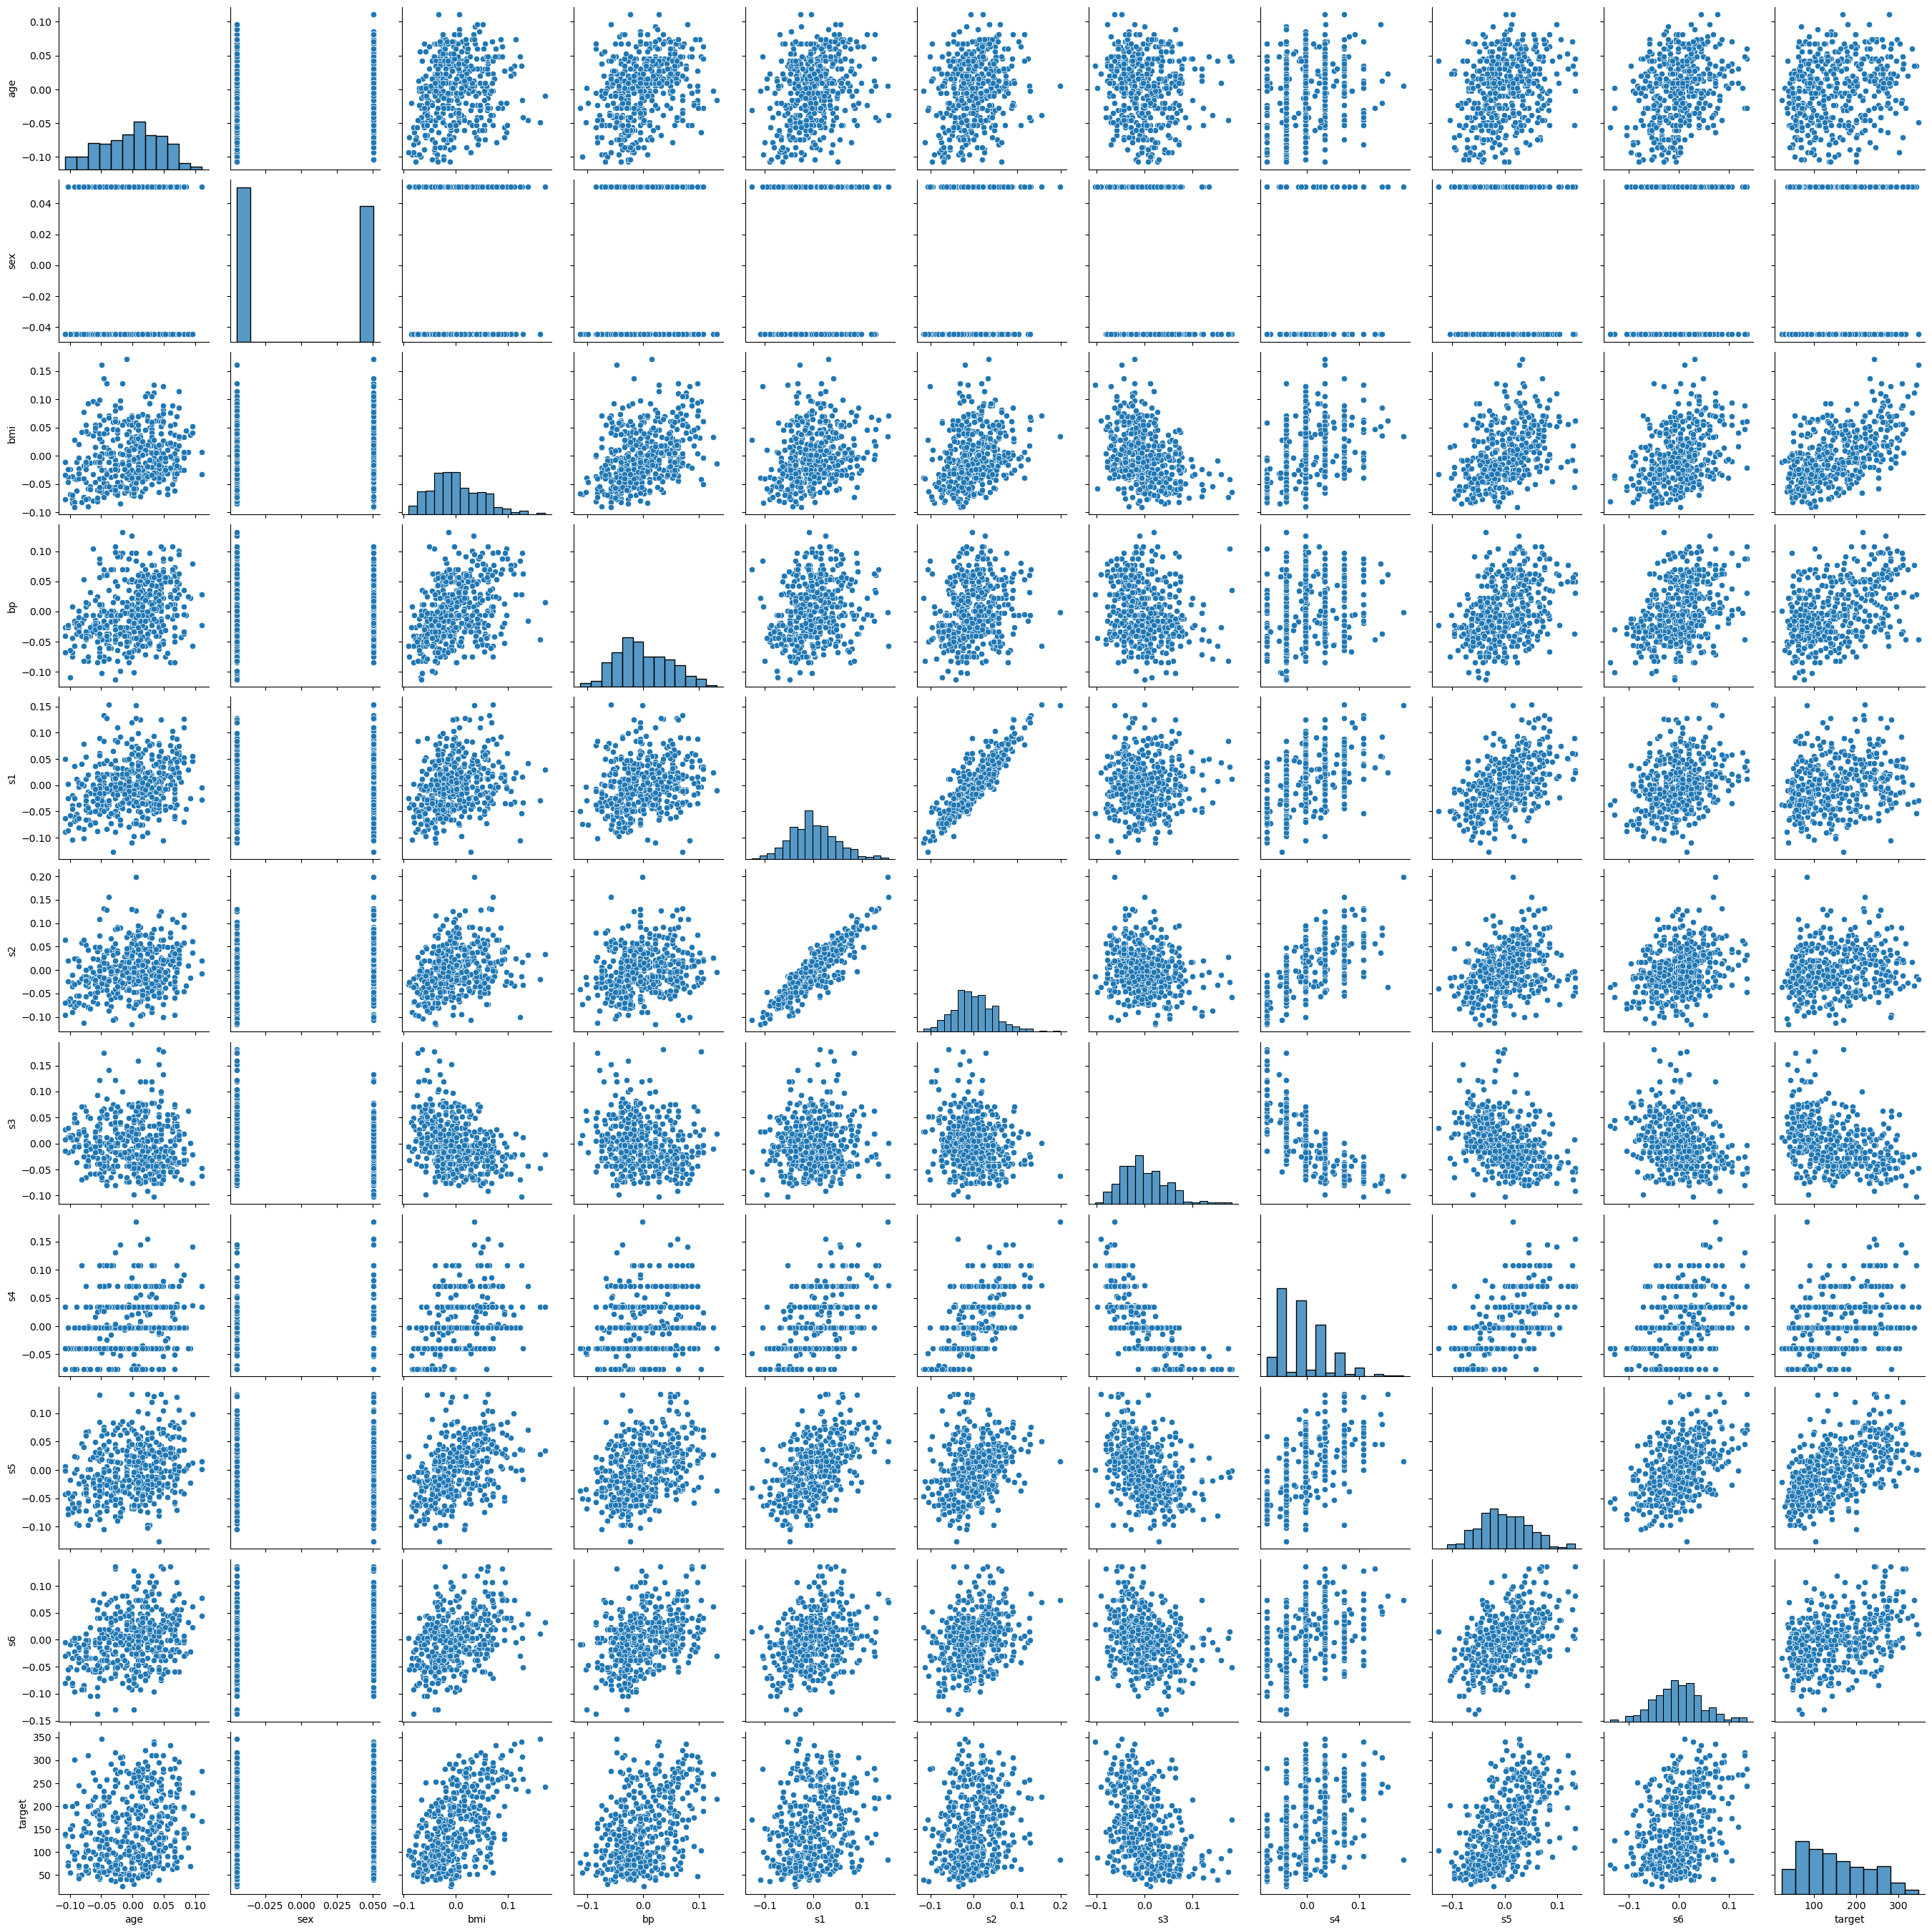

In [6]:
# see corelation between features and target
import seaborn as sns
sns.pairplot(diabetes_df)
plt.show()

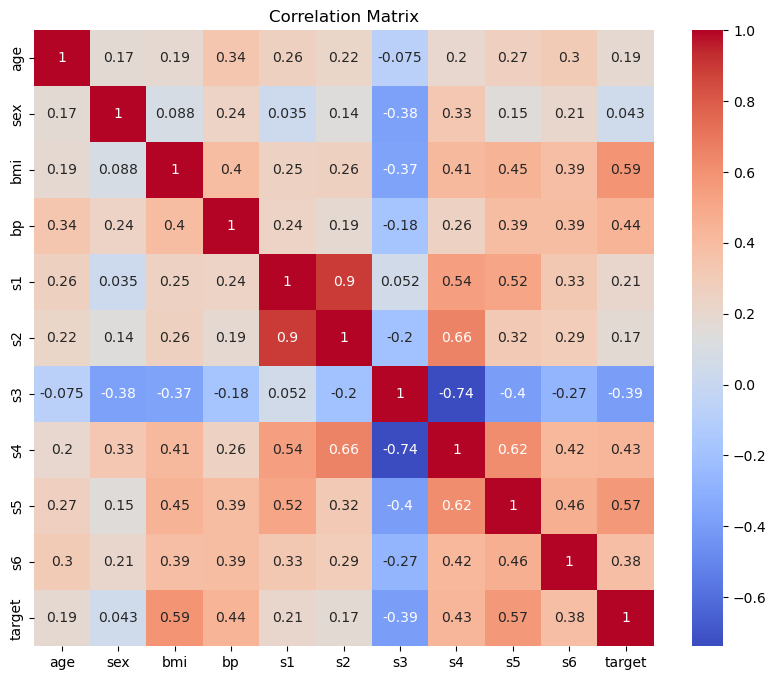

In [39]:
# Generate the corellation matrix between features and target
correlation_matrix = diabetes_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Plot shows high positive correlation between s1 and s2 and strong negative correlation between s3 and s4 variable.

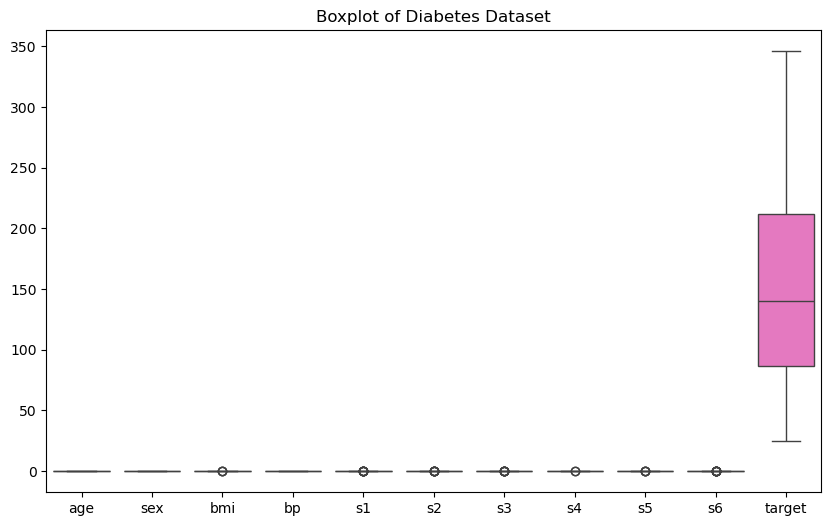

In [42]:
# detecting outliers using boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=diabetes_df)
plt.title('Boxplot of Diabetes Dataset')
plt.show()


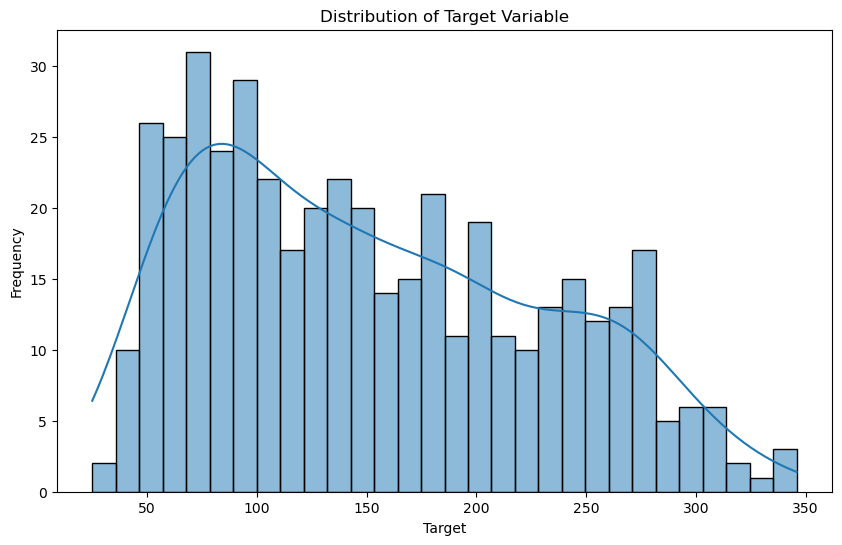

In [43]:
# plotting histogram to see the distribution of target variable
plt.figure(figsize=(10, 6))
sns.histplot(diabetes_df['target'], bins=30, kde=True)
plt.title('Distribution of Target Variable')
plt.xlabel('Target')
plt.ylabel('Frequency')
plt.show()


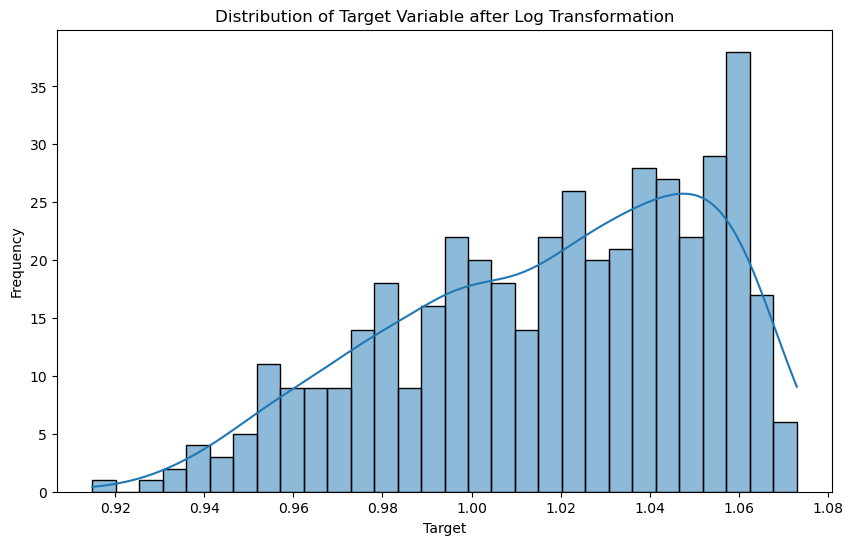

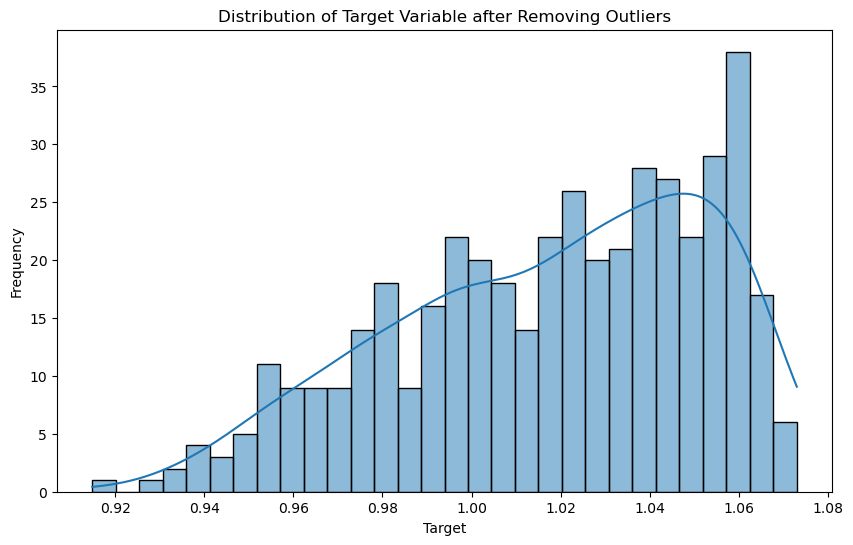

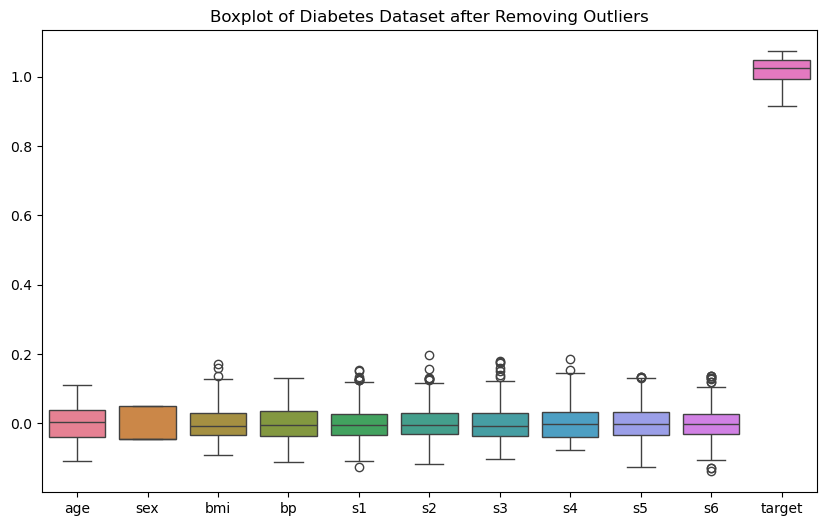

In [46]:
# the data is left skewed and has some outliers. We can apply log transformation to make it more normal distribution and remove outliers using IQR method.

# Applying log transformation to target variable
diabetes_df['target'] = np.log1p(diabetes_df['target'])

# check the distribution of target variable after log transformation
plt.figure(figsize=(10, 6))
sns.histplot(diabetes_df['target'], bins=30, kde=True)
plt.title('Distribution of Target Variable after Log Transformation')
plt.xlabel('Target')
plt.ylabel('Frequency')
plt.show()

# after log transformation the distribution of target variable is more normal and less skewed. Now we can remove outliers using IQR method.

# IQR method to remove outliers
Q1 = diabetes_df['target'].quantile(0.25)
Q3 = diabetes_df['target'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
diabetes_df = diabetes_df[(diabetes_df['target'] >= lower_bound) & (diabetes_df['target'] <= upper_bound)]
# check the distribution of target variable after removing outliers
plt.figure(figsize=(10, 6))
sns.histplot(diabetes_df['target'], bins=30, kde=True)
plt.title('Distribution of Target Variable after Removing Outliers')
plt.xlabel('Target')
plt.ylabel('Frequency')
plt.show()

# plotting the boxplot after removing outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=diabetes_df)
plt.title('Boxplot of Diabetes Dataset after Removing Outliers')
plt.show()


[ 8.05443606e-03 -1.16392968e-01  1.84070448e-01  1.29998757e-01
 -4.66222516e-01  3.81573150e-01  1.74859835e-02 -8.97366697e-03
  4.23093451e-01  4.39806096e-04]
1.0180596277400682
R-squared value: 0.4791429997682717


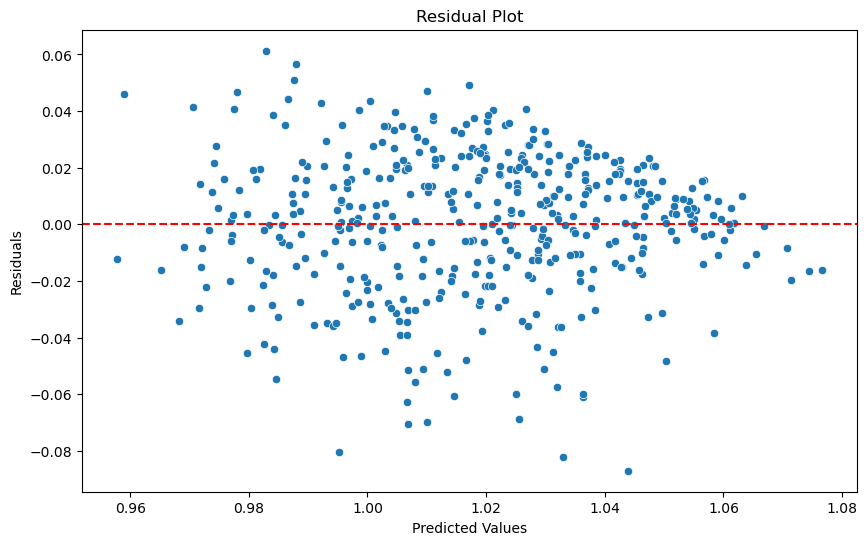

Mean Absolute Error: 0.019630327988589154


In [47]:
# Training the model with data after log transformation and removing outliers.

X = diabetes_df.drop('target', axis=1)
Y = diabetes_df['target']
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, Y)
print(model.coef_)  # slope of the line, tells how much does y change for a unit change in x
print(model.intercept_) # y-intercept of the line, tells the value of y when x is 0

# checking the performance of the model using R-squared value
from sklearn.metrics import r2_score
y_pred = model.predict(X)
r2 = r2_score(Y, y_pred)
print('R-squared value:', r2)

# checking goodness of fit using residual plot
residuals = Y - y_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

# checking accuracy of the model using mean absolute error
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(Y, y_pred)
print('Mean Absolute Error:', mae)



In [40]:
# creating a model removin highly correlated features
# removing s1 and s3 variable as they are highly correlated with s2 and s4 variable respectively
X = diabetes_df.drop(['s1', 's3', 'target'], axis=1)
y = diabetes_df['target']
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)
print(model.coef_)  # slope of the line, tells how much does y change for a unit change in x
print(model.intercept_) # y-intercept of the line, tells the value of y when x is 0


[ -14.07322148 -207.81579135  559.4070704   319.9931862  -274.41785652
  352.53494815  415.42162813   63.98782566]
152.13348416289605


In [50]:
# Check accuracy of the model
from sklearn.metrics import mean_squared_error


predicted = model.predict(X)
# total error of the model

mse = mean_squared_error(Y, predicted)
print(f"Mean Squared Error of the model: {mse:.2f}")
# Root Mean Squared Error
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error of the model: {rmse:.2f}")

Mean Squared Error of the model: 0.00
Root Mean Squared Error of the model: 0.02


In [7]:
# create a linear regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
# Check accuracy of the model
predicted = model.predict(X)
# total error of the model
total_error = np.sum((y - predicted) ** 2)
print(f"Total Error of the model: {total_error:.2f}")
# goodness of fit of the model
goodness_of_fit = 1 - (total_error / np.sum((y - np.mean(y)) ** 2))
print(f"Goodness of Fit of the model: {goodness_of_fit:.2f}")

Total Error of the model: 1263985.79
Goodness of Fit of the model: 0.52


In [22]:
print(model.coef_)  # slope of the line, tells how much does y change for a unit change in x
print(model.intercept_) # y-intercept of the line, tells the value of y when x is 0 

[ -10.0098663  -239.81564367  519.84592005  324.3846455  -792.17563855
  476.73902101  101.04326794  177.06323767  751.27369956   67.62669218]
152.13348416289597


In [9]:
# Improving the accuracy of the model by using only the most important features
# understanding the feature importance by looking at the absolute values of the coefficients
feature_importance = np.abs(model.coef_)
feature_names = diabetes.feature_names
for name, importance in zip(feature_names, feature_importance):
    print(f"Feature: {name}, Importance: {importance:.2f}")
    

Feature: age, Importance: 10.01
Feature: sex, Importance: 239.82
Feature: bmi, Importance: 519.85
Feature: bp, Importance: 324.38
Feature: s1, Importance: 792.18
Feature: s2, Importance: 476.74
Feature: s3, Importance: 101.04
Feature: s4, Importance: 177.06
Feature: s5, Importance: 751.27
Feature: s6, Importance: 67.63


In [21]:
# Improved Feature Selection Methods

# Method 1: Statistical Correlation with Target
print("=" * 60)
print("METHOD 1: CORRELATION-BASED FEATURE SELECTION")
print("=" * 60)
correlation_with_target = diabetes_df.corr()['target'].drop('target').abs().sort_values(ascending=False)
print("\nFeature Correlation with Target:")
print(correlation_with_target)

# Select top correlated features
top_corr_features = correlation_with_target.head(4).index.tolist()
X_corr = diabetes_df[top_corr_features].values
model_corr = LinearRegression()
model_corr.fit(X_corr, y)
predicted_corr = model_corr.predict(X_corr)
total_error_corr = np.sum((y - predicted_corr) ** 2)
goodness_of_fit_corr = 1 - (total_error_corr / np.sum((y - np.mean(y)) ** 2))
print(f"\nTop Correlated Features: {top_corr_features}")
print(f"Total Error (Correlation-Based): {total_error_corr:.2f}")
print(f"Goodness of Fit (Correlation-Based): {goodness_of_fit_corr:.4f}")

# Method 2: Mutual Information (Information-Based)
print("\n" + "=" * 60)
print("METHOD 2: MUTUAL INFORMATION-BASED FEATURE SELECTION")
print("=" * 60)
from sklearn.feature_selection import mutual_info_regression
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_df = pd.DataFrame({'Feature': feature_names, 'MI_Score': mi_scores}).sort_values('MI_Score', ascending=False)
print("\nMutual Information Scores:")
print(mi_df)

top_mi_features = mi_df.head(4)['Feature'].tolist()
X_mi = diabetes_df[top_mi_features].values
model_mi = LinearRegression()
model_mi.fit(X_mi, y)
predicted_mi = model_mi.predict(X_mi)
total_error_mi = np.sum((y - predicted_mi) ** 2)
goodness_of_fit_mi = 1 - (total_error_mi / np.sum((y - np.mean(y)) ** 2))
print(f"\nTop MI Features: {top_mi_features}")
print(f"Total Error (MI-Based): {total_error_mi:.2f}")
print(f"Goodness of Fit (MI-Based): {goodness_of_fit_mi:.4f}")

# Method 3: Recursive Feature Elimination (RFE)
print("\n" + "=" * 60)
print("METHOD 3: RECURSIVE FEATURE ELIMINATION (RFE)")
print("=" * 60)
from sklearn.feature_selection import RFE
rfe = RFE(LinearRegression(), n_features_to_select=4)
rfe.fit(X, y)
rfe_features = [feature_names[i] for i in range(len(feature_names)) if rfe.support_[i]]
X_rfe = diabetes_df[rfe_features].values
model_rfe = LinearRegression()
model_rfe.fit(X_rfe, y)
predicted_rfe = model_rfe.predict(X_rfe)
total_error_rfe = np.sum((y - predicted_rfe) ** 2)
goodness_of_fit_rfe = 1 - (total_error_rfe / np.sum((y - np.mean(y)) ** 2))
print(f"\nRFE Selected Features: {rfe_features}")
print(f"Total Error (RFE): {total_error_rfe:.2f}")
print(f"Goodness of Fit (RFE): {goodness_of_fit_rfe:.4f}")

# Comparison Summary
print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)
comparison_df = pd.DataFrame({
    'Model': ['All Features (10)', 'Coefficient-Based (3)', 'Correlation-Based (4)', 
              'Mutual Information (4)', 'RFE (4)'],
    'Goodness of Fit (R²)': [goodness_of_fit, goodness_of_fit_important, goodness_of_fit_corr, 
                             goodness_of_fit_mi, goodness_of_fit_rfe],
    'Total Error': [total_error, total_error_important, total_error_corr, total_error_mi, total_error_rfe]
})
print(comparison_df.to_string(index=False))

# Recommendation
best_r2 = comparison_df['Goodness of Fit (R²)'].idxmax()
print(f"\n✓ RECOMMENDED MODEL: {comparison_df.loc[best_r2, 'Model']}")
print(f"  R² Score: {comparison_df.loc[best_r2, 'Goodness of Fit (R²)']:.4f}")

METHOD 1: CORRELATION-BASED FEATURE SELECTION

Feature Correlation with Target:
bmi    0.586450
s5     0.565883
bp     0.441482
s4     0.430453
s3     0.394789
s6     0.382483
s1     0.212022
age    0.187889
s2     0.174054
sex    0.043062
Name: target, dtype: float64

Top Correlated Features: ['bmi', 's5', 'bp', 's4']
Total Error (Correlation-Based): 1359490.02
Goodness of Fit (Correlation-Based): 0.4813

METHOD 2: MUTUAL INFORMATION-BASED FEATURE SELECTION

Mutual Information Scores:
  Feature  MI_Score
2     bmi  0.175849
8      s5  0.145293
9      s6  0.110071
7      s4  0.107700
6      s3  0.066790
4      s1  0.065387
3      bp  0.055903
1     sex  0.017674
5      s2  0.012951
0     age  0.001469

Top MI Features: ['bmi', 's5', 's6', 's4']
Total Error (MI-Based): 1408531.73
Goodness of Fit (MI-Based): 0.4626

METHOD 3: RECURSIVE FEATURE ELIMINATION (RFE)

RFE Selected Features: ['bmi', 's1', 's2', 's5']
Total Error (RFE): 1372163.30
Goodness of Fit (RFE): 0.4765

MODEL COMPARISON 

In [34]:
# add polynomial features to improve the model
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
model_poly = LinearRegression()
model_poly.fit(X_poly, y)
predicted_poly = model_poly.predict(X_poly)
total_error_poly = np.sum((y - predicted_poly) ** 2)
goodness_of_fit_poly = 1 - (total_error_poly / np.sum((y - np.mean(y)) ** 2))
print("\n" + "=" * 60)
print("MODEL WITH POLYNOMIAL FEATURES")
print("=" * 60)
print(f"Total Error (Polynomial): {total_error_poly:.2f}")
print(f"Goodness of Fit (Polynomial): {goodness_of_fit_poly:.4f}")
# calulating the R2 score for the polynomial model
from sklearn.metrics import r2_score
r2_poly = r2_score(y, predicted_poly)
print(f"R² Score (Polynomial): {r2_poly:.4f}")


# printing the best fit equation
print("\n" + "=" * 60)
print("BEST FIT EQUATION (POLYNOMIAL FEATURES)")
print("=" * 60)
feature_names_poly = poly.get_feature_names_out(feature_names)
equation_terms = [f"{coef:.4f}*{name}" for coef, name in zip(model_poly.coef_, feature_names_poly)]
equation = " + ".join(equation_terms)
print(f"Predicted Target = {model_poly.intercept_:.4f} + {equation}")


MODEL WITH POLYNOMIAL FEATURES
Total Error (Polynomial): 1068217.76
Goodness of Fit (Polynomial): 0.5924
R² Score (Polynomial): 0.5924

BEST FIT EQUATION (POLYNOMIAL FEATURES)
Predicted Target = 124.3506 + 50.7183*age + -267.3390*sex + 460.7384*bmi + 342.9252*bp + -3733.8212*s1 + 3146.2961*s2 + 1153.2305*s3 + 74.9353*s4 + 1872.3642*s5 + 62.7475*s6 + 1237.4922*age^2 + 3179.9210*age sex + -379.2277*age bmi + 415.9756*age bp + -3253.2265*age s1 + -1413.7627*age s2 + 4869.9829*age s3 + 4000.4990*age s4 + 2627.3642*age s5 + 1398.3364*age s6 + -1.6143*sex^2 + 1371.0127*sex bmi + 1929.2560*sex bp + 9069.3625*sex s1 + -7454.9276*sex s2 + -2861.0875*sex s3 + -2904.9939*sex s4 + -2525.7122*sex s5 + 985.1858*sex s6 + 668.1158*bmi^2 + 3061.7663*bmi bp + -6580.8834*bmi s1 + 5321.8284*bmi s2 + 2730.6868*bmi s3 + -733.4891*bmi s4 + 2530.7903*bmi s5 + 487.1108*bmi s6 + -147.5584*bp^2 + 10320.3620*bp s1 + -7116.4030*bp s2 + -3851.5239*bp s3 + -1260.9280*bp s4 + -3467.9914*bp s5 + -2710.4689*bp s6 + 93


PREDICTION ON NEW DATA
Input Features: [0.05 0.02 0.03 0.01 0.04 0.02 0.03 0.01 0.04 0.02]
Predicted Target Value: 195.18


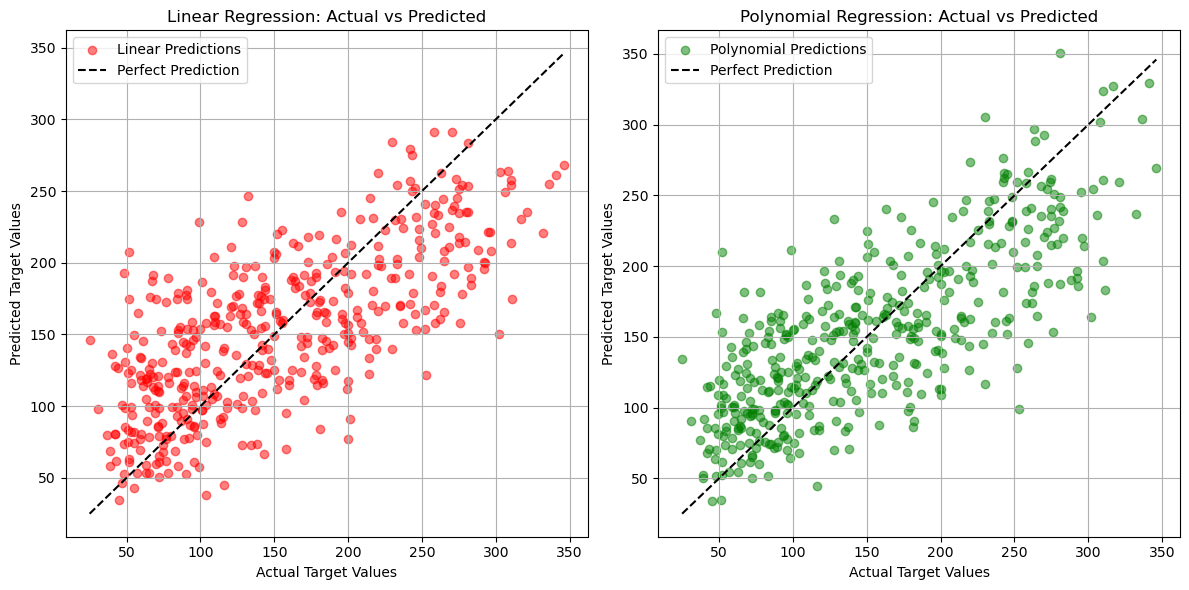

In [33]:
# predicting on new data
new_data = np.array([[0.05, 0.02, 0.03, 0.01, 0.04, 0.02, 0.03, 0.01, 0.04, 0.02]])
new_data_poly = poly.transform(new_data)
predicted_new = model_poly.predict(new_data_poly)
print("\n" + "=" * 60)  
print("PREDICTION ON NEW DATA")
print("=" * 60)
print(f"Input Features: {new_data.flatten()}")
print(f"Predicted Target Value: {predicted_new[0]:.2f}")

# Visualize Actual vs Predicted Values for both models
# Since X has 10 dimensions, we plot actual vs predicted values instead of features vs target
plt.figure(figsize=(12, 6))

# Plot 1: Actual vs Predicted for Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y, predicted, color='red', alpha=0.5, label='Linear Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label='Perfect Prediction')
plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Target Values')
plt.title('Linear Regression: Actual vs Predicted')
plt.legend()
plt.grid()

# Plot 2: Actual vs Predicted for Polynomial Regression
plt.subplot(1, 2, 2)
plt.scatter(y, predicted_poly, color='green', alpha=0.5, label='Polynomial Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label='Perfect Prediction')
plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Target Values')
plt.title('Polynomial Regression: Actual vs Predicted')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

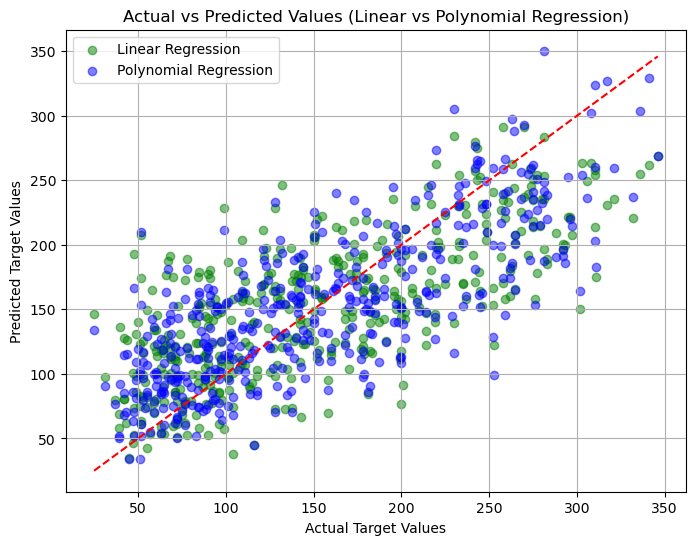

In [ ]:
# generate the graph of 1st model and the polynomial model
plt.figure(figsize=(8, 6))
plt.scatter(y, predicted, color='green', alpha=0.5, label='Linear Regression')
plt.scatter(y, predicted_poly, color='blue', alpha=0.5, label='Polynomial Regression')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Line for perfect predictions
plt.xlabel('Actual Target Values')
plt.ylabel('Predicted Target Values')
plt.title('Actual vs Predicted Values (Linear vs Polynomial Regression)')
plt.legend()
plt.grid()
plt.show()